In [ ]:
# Flag indicating if user wants to run all experiments
run_all_experiments = False

In [1]:
import pandas as pd

# Get train and test data (these were pre-split)
url = "https://media.githubusercontent.com/media/AarejSyed/Labelled-Kepler-Light-Curve-Dataset/refs/heads/main/"
train = pd.read_csv(url+"exoTrain.csv")
test  = pd.read_csv(url+"exoTest.csv")

print(train.shape, test.shape)

(5087, 3198) (570, 3198)


In [2]:
train.head()

,LABEL,FLUX.1,FLUX.2,FLUX.3,FLUX.4,FLUX.5,FLUX.6,FLUX.7,FLUX.8,FLUX.9,...,FLUX.3188,FLUX.3189,FLUX.3190,FLUX.3191,FLUX.3192,FLUX.3193,FLUX.3194,FLUX.3195,FLUX.3196,FLUX.3197
0,2,93.85,83.81,20.10,-26.98,-39.56,-124.71,-135.18,-96.27,-79.89,...,-78.07,-102.15,-102.15,25.13,48.57,92.54,39.32,61.42,5.08,-39.54
1,2,-38.88,-33.83,-58.54,-40.09,-79.31,-72.81,-86.55,-85.33,-83.97,...,-3.28,-32.21,-32.21,-24.89,-4.86,0.76,-11.70,6.46,16.00,19.93
2,2,532.64,535.92,513.73,496.92,456.45,466.00,464.50,486.39,436.56,...,-71.69,13.31,13.31,-29.89,-20.88,5.06,-11.80,-28.91,-70.02,-96.67
3,2,326.52,347.39,302.35,298.13,317.74,312.70,322.33,311.31,312.42,...,5.71,-3.73,-3.73,30.05,20.03,-12.67,-8.77,-17.31,-17.35,13.98
4,2,-1107.21,-1112.59,-1118.95,-1095.10,-1057.55,-1034.48,-998.34,-1022.71,-989.57,...,-594.37,-401.66,-401.66,-357.24,-443.76,-438.54,-399.71,-384.65,-411.79,-510.54


In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5087 entries, 0 to 5086
Columns: 3198 entries, LABEL to FLUX.3197
dtypes: float64(3197), int64(1)
memory usage: 124.1 MB


In [4]:
train.isna().sum().sum()
# result = 0 -> no missing values

np.int64(0)

In [5]:
# count how many samples in each class
# see if dataset is balanced or not
train["LABEL"].value_counts()

,count
LABEL,
1,5050
2,37


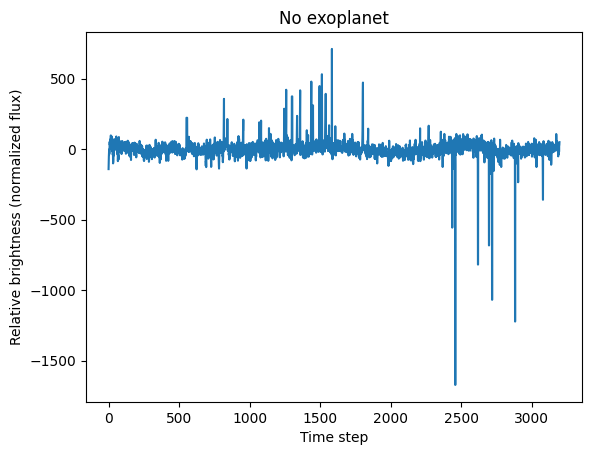

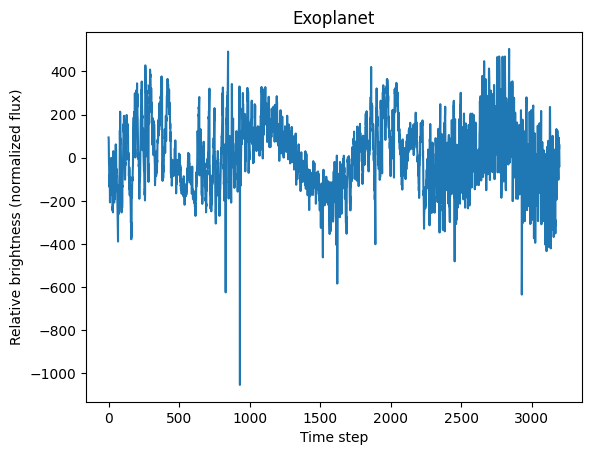

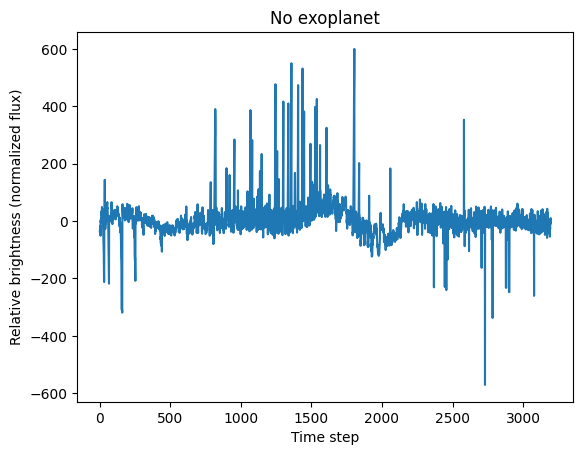

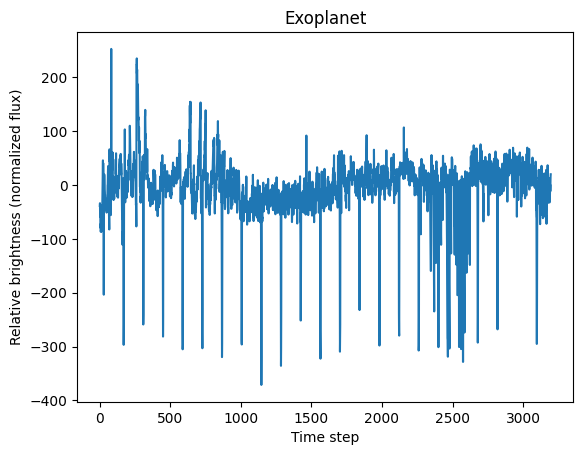

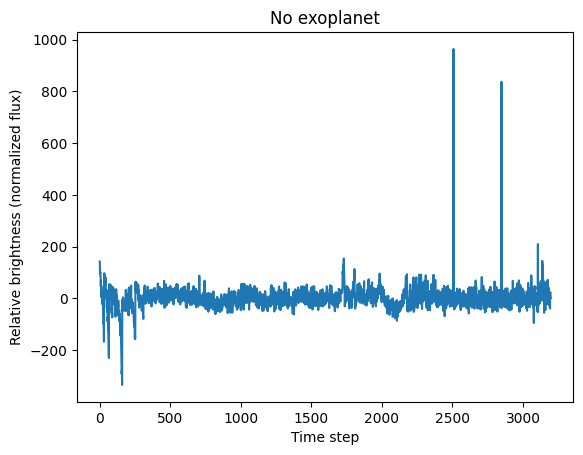

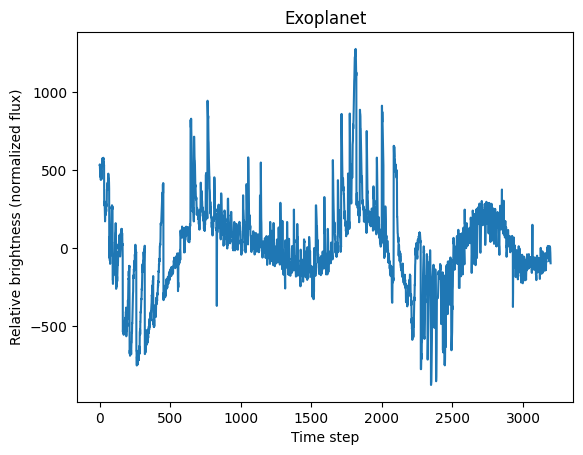

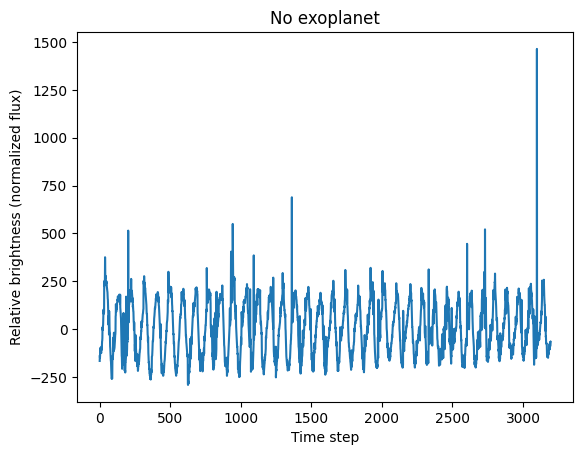

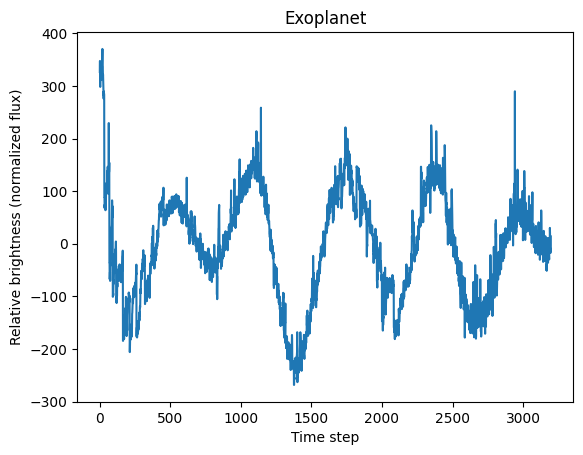

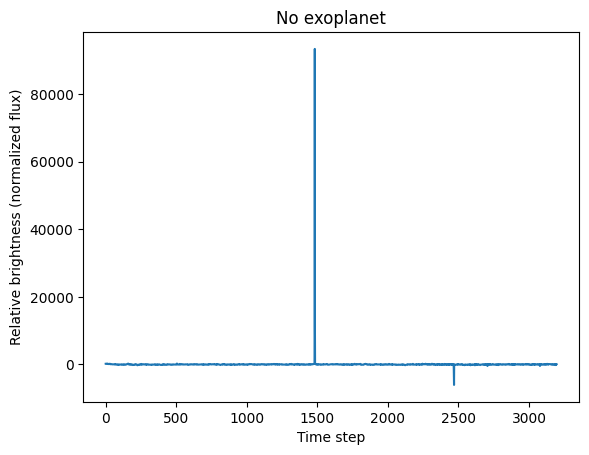

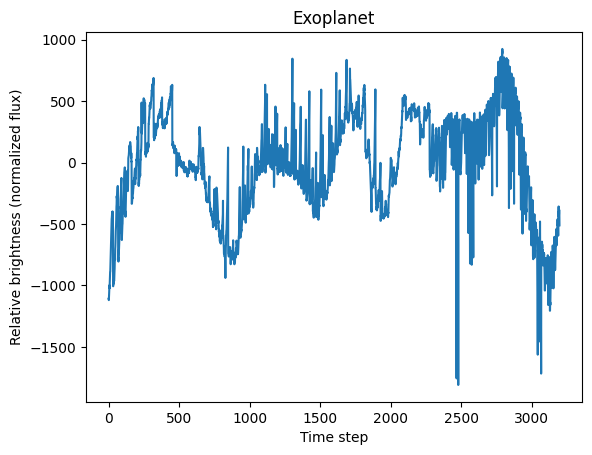

In [6]:
import matplotlib.pyplot as plt

# plot 5 examples from each class to see difference in shape
for i in range(5):
  # class 1 (no exoplanet)
  plt.plot(train[train["LABEL"] == 1].iloc[i, 1:].values)
  # take first sample in class 1, ignore label column, plot flux values
  plt.title("No exoplanet")
  plt.xlabel("Time step")
  plt.ylabel("Relative brightness (normalized flux)")
  plt.show()

  # class 2 (exoplanet)
  plt.plot(train[train["LABEL"] == 2].iloc[i, 1:].values)
  # take first sample in class 2, plot flux values
  plt.title("Exoplanet")
  plt.xlabel("Time step")
  plt.ylabel("Relative brightness (normalized flux)")
  plt.show()

# curves are noisy, but this gives us a quick idea of the light curve shape

In [7]:
# check class distribution (%)
# clearly very imbalanced (~99% no exoplanet)
train["LABEL"].value_counts(normalize=True) * 100

,proportion
LABEL,
1,99.272656
2,0.727344


In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [9]:
# separate X and y
# -1 to make label start from 0 instead of 1
X_train_full = train.drop("LABEL", axis=1).values
y_train_full = train["LABEL"].values - 1

X_test = test.drop("LABEL", axis=1).values
y_test = test["LABEL"].values - 1

In [10]:
# split train into train + val (80/20)
# stratify to keep same ratio because data is very imbalanced
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

In [11]:
# standardize data
# fit only on train to avoid leakage
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)


In [12]:
# reshape for 1D CNN (add channel dim)
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val = X_val.reshape(X_val.shape[0], X_val.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

In [13]:
# check shape of each split (after reshape for CNN)
print("Shapes:")
print(X_train.shape, X_val.shape, X_test.shape)


# check number of samples in each class (0 = no exoplanet, 1 = exoplanet)
# to make sure split is correct
print("\nClass counts:")
print("Train: ", pd.Series(y_train).value_counts())
print("Val:", pd.Series(y_val).value_counts())
print("Test:", pd.Series(y_test).value_counts())

Shapes:
(4069, 3197, 1) (1018, 3197, 1) (570, 3197, 1)

Class counts:
Train:  0    4039
1      30
Name: count, dtype: int64
Val: 0    1011
1       7
Name: count, dtype: int64
Test: 0    565
1      5
Name: count, dtype: int64


In [14]:
# check ratio again (just to confirm stratify worked)
print("Train ratio:", pd.Series(y_train).value_counts(normalize=True))
print("Val ratio:", pd.Series(y_val).value_counts(normalize=True))

Train ratio: 0    0.992627
1    0.007373
Name: proportion, dtype: float64
Val ratio: 0    0.993124
1    0.006876
Name: proportion, dtype: float64


In [15]:
# quick summary of first few raw features
print(train.describe().iloc[:, :5])

             LABEL        FLUX.1        FLUX.2        FLUX.3        FLUX.4
count  5087.000000  5.087000e+03  5.087000e+03  5.087000e+03  5.087000e+03
mean      1.007273  1.445054e+02  1.285778e+02  1.471348e+02  1.561512e+02
std       0.084982  2.150669e+04  2.179717e+04  2.191309e+04  2.223366e+04
min       1.000000 -2.278563e+05 -3.154408e+05 -2.840018e+05 -2.340069e+05
25%       1.000000 -4.234000e+01 -3.952000e+01 -3.850500e+01 -3.505000e+01
50%       1.000000 -7.100000e-01 -8.900000e-01 -7.400000e-01 -4.000000e-01
75%       1.000000  4.825500e+01  4.428500e+01  4.232500e+01  3.976500e+01
max       2.000000  1.439240e+06  1.453319e+06  1.468429e+06  1.495750e+06


In [16]:
import numpy as np

def relu(x):
  return np.maximum(0, x)

def relu_grad(x):
  return (x > 0).astype(float)

def sigmoid(x):
  x = np.clip(x, -500, 500)
  return 1.0 / (1.0 + np.exp(-x))

def weighted_bce(y_true, y_pred, pos_weight, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    weights = np.where(y_true == 1, pos_weight, 1.0)
    return -np.mean(weights * (y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred)))

def weighted_bce_grad(y_true, y_pred, pos_weight, eps=1e-8):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    weights = np.where(y_true == 1, pos_weight, 1.0)

    # Normalized so gradients don't explode when y_pred is near 0 or 1
    return weights * (y_pred - y_true) / len(y_true)

print("Activations and loss functions defined")

Activations and loss functions defined


In [17]:
# Clips gradients so they don't explode
def clip_gradients(dW, db, clip_value=5.0):
  dW_clipped = np.clip(dW, -clip_value, clip_value)
  db_clipped = np.clip(db, -clip_value, clip_value)

  return dW_clipped, db_clipped

In [18]:
class Conv1D:
  def __init__(self, in_channels, out_channels, kernel_size, stride=1):
    self.in_channels = in_channels
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.stride = stride

    scale = np.sqrt(2.0 / (in_channels * kernel_size))
    self.W = np.random.randn(out_channels, in_channels, kernel_size) * scale
    self.b = np.zeros(out_channels)
    self._x = None

  def forward(self, x):
    self._x = x
    batch, L, C_in = x.shape
    L_out = (L - self.kernel_size) // self.stride + 1
    out   = np.zeros((batch, L_out, self.out_channels))

    for f in range(self.out_channels):
      for i in range(L_out):
        start = i * self.stride
        patch = x[:, start:start + self.kernel_size, :]  # (batch, k, C_in)
        out[:, i, f] = np.tensordot(patch, self.W[f], axes=([1, 2], [1, 0])) + self.b[f]

    return out

  def backward(self, d_out, lr):
    x = self._x
    batch, L, C_in = x.shape
    L_out = d_out.shape[1]

    dW = np.zeros_like(self.W)
    db = np.zeros_like(self.b)
    dx = np.zeros_like(x)

    for f in range(self.out_channels):
      for i in range(L_out):
        start = i * self.stride
        patch = x[:, start:start + self.kernel_size, :]
        grad_f = d_out[:, i, f]
        dW[f] += np.tensordot(grad_f, patch, axes=([0], [0])).T
        db[f] += np.sum(grad_f)
        dx[:, start:start + self.kernel_size, :] += (
          grad_f[:, np.newaxis, np.newaxis] * self.W[f].T[np.newaxis]
        )

    # Clip gradients before updating weights
    dW, db = clip_gradients(dW, db)

    self.W -= lr * dW
    self.b -= lr * db
    return dx

print("Conv1D defined")

Conv1D defined


In [19]:
class MaxPool1D:
  def __init__(self, pool_size):
    self.pool_size = pool_size
    self.x = None

  def forward(self, x):
    self._x = x
    batch, L, C = x.shape
    L_out = L // self.pool_size
    out   = np.zeros((batch, L_out, C))

    for i in range(L_out):
      s = i * self.pool_size
      out[:, i, :] = np.max(x[:, s:s + self.pool_size, :], axis=1)

    return out

  def backward(self, d_out):
    x  = self._x
    dx = np.zeros_like(x)

    for i in range(d_out.shape[1]):
      s = i * self.pool_size
      patch = x[:, s:s + self.pool_size, :]
      max_vals = np.max(patch, axis=1, keepdims=True)
      mask = (patch == max_vals)
      mask = mask / (mask.sum(axis=1, keepdims=True) + 1e-8)
      dx[:, s:s + self.pool_size, :] += mask * d_out[:, i:i+1, :]

    return dx

print("MaxPool1D defined")

MaxPool1D defined


In [20]:
class Dense:
  def __init__(self, in_features, out_features):
    scale = np.sqrt(2.0 / in_features)
    self.W = np.random.randn(in_features, out_features) * scale
    self.b = np.zeros(out_features)
    self._x = None

  def forward(self, x):
    self._x = x
    return x @ self.W + self.b

  def backward(self, d_out, lr):
    x = self._x
    dW = x.T @d_out
    db = np.sum(d_out, axis=0)
    dx = d_out @ self.W.T

    # Clip gradients before updating weights
    dW, db = clip_gradients(dW, db)

    self.W -= lr * dW
    self.b -= lr * db
    return dx

print("Dense defined")

Dense defined


In [21]:
import time

class CNN1D:
  def __init__(self, input_length=3197, lr=0.0001, pos_weight=50.0, out_channels=(16, 32), kernel_size=(7, 5)):
    self.lr = lr
    self.pos_weight = pos_weight

    self.conv1 = Conv1D(in_channels=1,  out_channels=out_channels[0], kernel_size=kernel_size[0])
    self.pool1 = MaxPool1D(pool_size=4)
    self.conv2 = Conv1D(in_channels=out_channels[0], out_channels=out_channels[1], kernel_size=kernel_size[1])
    self.pool2 = MaxPool1D(pool_size=4)

    l1 = (input_length - kernel_size[0]) // 1 + 1
    l1 = l1 // 4
    l2 = (l1 - kernel_size[1]) // 1 + 1
    l2 = l2 // 4
    self.flat_size = l2 * out_channels[1]
    print(f"Flattened size after conv/pool layers: {self.flat_size}")

    self.dense1 = Dense(self.flat_size, 64)
    self.dense2 = Dense(64, 1)
    self._cache = {}

  def forward(self, x):
    out = self.conv1.forward(x)
    self._cache['relu1_in'] = out
    out = relu(out)
    self._cache['relu1']    = out
    out = self.pool1.forward(out)

    out = self.conv2.forward(out)
    self._cache['relu2_in'] = out
    out = relu(out)
    self._cache['relu2']    = out
    out = self.pool2.forward(out)
    self._cache['pool2_shape'] = out.shape

    out = out.reshape(out.shape[0], -1)

    out = self.dense1.forward(out)
    self._cache['relu3_in'] = out
    out = relu(out)
    self._cache['relu3']    = out

    out = self.dense2.forward(out)
    return sigmoid(out).squeeze(-1)

  def backward(self, y_true, y_pred):
    lr = self.lr
    d  = weighted_bce_grad(y_true, y_pred, self.pos_weight)[:, np.newaxis]

    d = self.dense2.backward(d, lr)
    d = d * relu_grad(self._cache['relu3'])
    d = self.dense1.backward(d, lr)

    d = d.reshape(self._cache['pool2_shape'])

    d = self.pool2.backward(d)
    d = d * relu_grad(self._cache['relu2'])
    d = self.conv2.backward(d, lr)

    d = self.pool1.backward(d)
    d = d * relu_grad(self._cache['relu1'])
    self.conv1.backward(d, lr)

  def train(self, X_train, y_train, epochs, batch_size = 128):
    # Get training start time
    train_start_time = time.time()

    for epoch in range(epochs):
      # Get epoch start time
      start_time = time.time()

      # Shuffle training set for each epoch
      indices = np.random.permutation(len(X_train))
      X_train_shuffled = X_train[indices]
      y_train_shuffled = y_train[indices]

      for i in range(0, len(X_train_shuffled), batch_size):
        x = X_train_shuffled[i:i+batch_size]
        y_real = y_train_shuffled[i:i+batch_size]

        y_pred = self.forward(x)
        self.backward(y_real, y_pred)

      print(f"Epoch {epoch + 1}/{epochs} completed in {(time.time() - start_time):.2f} seconds!")

    # Return total training time
    return time.time() - train_start_time

  def predict(self, x, threshold=0.5):
    return (self.forward(x) >= threshold).astype(int)

print("CNN1D defined")

CNN1D defined


In [23]:
from itertools import product
from sklearn.metrics import classification_report

# Set random seed for consistency
base_seed = 51
np.random.seed(base_seed)

# Epoch count
epochs = 10

# Lists of hyperparameters to test
pos_weights = [100, 150] if run_all_experiments else [100]
out_channel_counts = [(16, 32), (32, 32)] if run_all_experiments else [(16, 32)]

In [24]:
# Tracks best model
best_val_f1 = -100
best_experiment_num = -1
best_model = None
best_hyperparameters = None

# Experiment number
experiment_num = 1

# Get experiment file path
experiments_file_path = "experiments.txt"

# Test all combinations of hyperparameters
for pos_weight, out_channels in product(pos_weights, out_channel_counts):
  # Set random seed for experiment
  experiment_seed = base_seed + experiment_num
  np.random.seed(experiment_seed)

  # Open experiment tracking file
  with open(experiments_file_path, 'a') as experiments_file:
    # Experiment heading in file
    experiments_file.write(
        f"EXPERIMENT {experiment_num}\n\n"
    )

    # Save experiment parameters
    experiments_file.write(
        f"Parameters:\n"
        f"\tSeed: {experiment_seed}\n"
        f"\tPositive class weight: {pos_weight}\n"
        f"\tFilter counts: {out_channels}\n"
        f"\n"
    )

  # Notify user of experiment start
  print(
      f"Started experiment {experiment_num}!\n"
      f"Hyperparameters: pos_weight={pos_weight}, out_channels={out_channels}"
  )

  # Create model
  model = CNN1D(
      pos_weight=pos_weight,
      out_channels=out_channels
  )

  # Train model
  train_time = model.train(X_train, y_train, epochs)

  # Get y val predictions
  y_val_pred = model.predict(X_val)

  # Get val F1 score
  report = classification_report(y_val, y_val_pred, output_dict=True)
  val_f1 = report['1']["f1-score"]

  # If val F1 has improved, this is our new best model
  if val_f1 > best_val_f1:
    best_val_f1 = val_f1
    best_experiment_num = experiment_num
    best_model = model
    best_hyperparameters = (pos_weight, out_channels)

  # Save training and validation results for model
  with open(experiments_file_path, 'a') as experiments_file:
    experiments_file.write(
        f"Training time: {train_time:.2f}\n"
        f"Training:\n"
        f"{classification_report(y_train, model.predict(X_train))}\n\n"
        f"Validation:\n"
        f"{classification_report(y_val, y_val_pred)}\n\n"
    )

  # Notify user of experiment completion
  print(f"Experiment {experiment_num} complete!")

  # Increment experiment number for next experiment
  experiment_num += 1

Started experiment 1!
Hyperparameters: pos_weight=50, out_channels=(8, 8)
Flattened size after conv/pool layers: 1584
Epoch 1/1 completed in 52.97 seconds!
Experiment 1 complete!


In [25]:
from google.colab import files

# Get testing predictions for best model
y_test_pred = best_model.predict(X_test)

# Write testing results for best model to experiments file
with open(experiments_file_path, 'a') as experiments_file:
  experiments_file.write(
      f"BEST EXPERIMENT: {best_experiment_num}\n"
      f"Hyperparameters: pos_weight={best_hyperparameters[0]}, out_channels={best_hyperparameters[1]}\n"
      f"Validation F1 score: {best_val_f1:.4f}\n"
      f"Testing:\n"
      f"{classification_report(y_test, y_test_pred)}"
  )

files.download(experiments_file_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

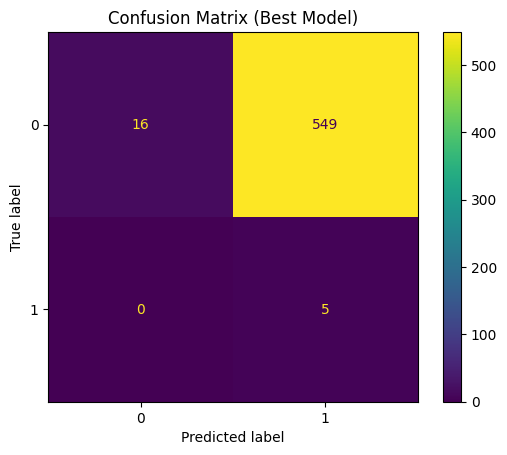

In [26]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Use testing predictions to create confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm)
cm_display.plot()
plt.title("Confusion Matrix (Best Model)")
plt.show()

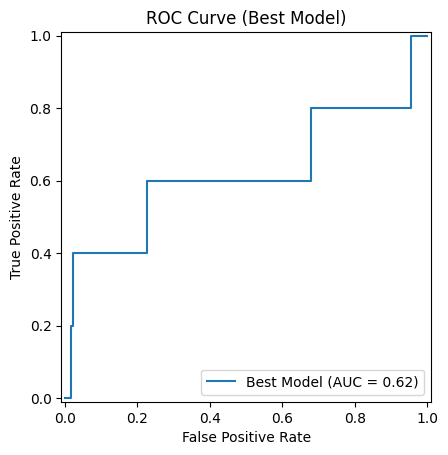

In [27]:
from sklearn.metrics import roc_curve, auc, RocCurveDisplay

# Use testing predictions to create ROC plot
false_pos_rate, true_pos_rate, _ = roc_curve(y_test, best_model.forward(X_test))
roc_auc = auc(false_pos_rate, true_pos_rate)
roc_display = RocCurveDisplay(fpr=false_pos_rate, tpr=true_pos_rate, roc_auc=roc_auc,
                                  estimator_name="Best Model")
roc_display.plot()
plt.title("ROC Curve (Best Model)")
plt.show()